# Molecular Graph Learning Curve

This notebook measures how predictive performance on the MoleculeNet HIV dataset changes as the number of training graphs increases, using `NSPPK` features with `radius=1`, `distance=4`, `connector=1` and a linear `SGDClassifier`.

The evaluation uses one fixed stratified train/test split. For each repeat, the training molecules are reordered with a new seed, vectorized in streamed batches, and consumed incrementally through `SGDClassifier.partial_fit(...)` while the same held-out test set is scored at fixed training-size checkpoints.


In [ ]:
from numbers import Integral, Real
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rdkit import Chem, RDLogger
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split

REPO_CANDIDATES = [Path.cwd().resolve(), Path.cwd().resolve().parent]
REPO_ROOT = next(candidate for candidate in REPO_CANDIDATES if (candidate / 'src').exists())
SRC_DIR = REPO_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from graph_io import _rdkit_mol_to_nx_graph
from nsppk import NSPPK
from utils import plot_series_with_band_loess

DATASET_URL = 'https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/HIV.csv'
DATASET_FILE = REPO_ROOT / 'data' / 'HIV.csv'
NBIT = 14
RADIUS = 1
DISTANCE = 4
CONNECTOR = 1
LIMIT = 8000
BALANCE_DATASET = True
TRAIN_FRACTION = 0.7
TEST_SIZE = 1 - TRAIN_FRACTION
TRAIN_SIZE_VALUES = [250, 500, 1000, 2000, 4000]
N_REPEATS = 3
BATCH_SIZE = 256
WARMUP_SIZE = 256
PARALLEL = True
RANDOM_STATE = 42

RDLogger.DisableLog('rdApp.*')



## Load dataset metadata

The notebook keeps only SMILES strings and labels in memory for the full dataset. Graph objects are materialized only for a small warmup set, the fixed test split, and each streamed training batch.


In [ ]:
metadata = pd.read_csv(DATASET_FILE, usecols=['smiles', 'HIV_active'])
metadata['HIV_active'] = metadata['HIV_active'].astype(int)
original_dataset_size = len(metadata)
valid_smiles_mask = metadata['smiles'].map(lambda smiles: Chem.MolFromSmiles(smiles) is not None)
metadata = metadata.loc[valid_smiles_mask].reset_index(drop=True)


def sample_metadata_frame(frame, limit=None, balance=False, random_state=None):
    rng = np.random.default_rng(random_state)

    if balance:
        labels = frame['HIV_active'].to_numpy()
        unique_labels = np.sort(np.unique(labels))
        class_indices = {label: np.flatnonzero(labels == label) for label in unique_labels}
        minority_count = min(len(indices) for indices in class_indices.values())
        target_size = len(frame) if limit is None else min(int(limit), len(frame))
        per_class = min(minority_count, target_size // len(unique_labels))
        remainder = target_size - per_class * len(unique_labels)

        selected_parts = []
        leftover_parts = []
        for label in unique_labels:
            permuted = rng.permutation(class_indices[label])
            selected_parts.append(permuted[:per_class])
            leftover_parts.append(permuted[per_class:])

        selected_idx = np.concatenate(selected_parts) if selected_parts else np.empty(0, dtype=int)
        if remainder > 0:
            leftovers = np.concatenate([part for part in leftover_parts if len(part)])
            if len(leftovers):
                extra_idx = rng.choice(leftovers, size=min(remainder, len(leftovers)), replace=False)
                selected_idx = np.concatenate([selected_idx, extra_idx])

        return frame.iloc[np.sort(selected_idx)].reset_index(drop=True)

    if limit is None:
        return frame.reset_index(drop=True)
    if isinstance(limit, Integral) and not isinstance(limit, bool):
        return frame.iloc[:int(limit)].reset_index(drop=True)
    if isinstance(limit, Real) and not isinstance(limit, Integral):
        mask = rng.random(len(frame)) < float(limit)
        return frame.loc[mask].reset_index(drop=True)
    raise ValueError('limit must be None, a non-negative integer, or a float strictly between 0 and 1.')


def make_dataframe_reader(frame):
    records = list(frame[['smiles', 'HIV_active']].itertuples(index=False, name=None))

    def reader(_):
        for row_number, (smiles, label) in enumerate(records, start=2):
            mol = Chem.MolFromSmiles(smiles)
            if mol is None:
                raise ValueError(f'Invalid SMILES encountered after metadata filtering: {smiles!r}')
            graph = _rdkit_mol_to_nx_graph(mol)
            graph.graph['smiles'] = smiles
            graph.graph['HIV_active'] = int(label)
            graph.graph['name'] = str(int(label))
            graph.graph['source_uri'] = str(DATASET_FILE)
            graph.graph['source_line'] = row_number
            yield graph

    return reader


def materialize_graphs(frame):
    return list(make_dataframe_reader(frame)(None))


def iter_vectorized_batches(vectorizer, frame, labels, batch_size, checkpoint_sizes):
    stop_positions = set(range(batch_size, len(frame), batch_size))
    stop_positions.update(int(size) for size in checkpoint_sizes)
    stop_positions.add(len(frame))

    start = 0
    for stop in sorted(pos for pos in stop_positions if 0 < pos <= len(frame)):
        batch_frame = frame.iloc[start:stop]
        batch_graphs = materialize_graphs(batch_frame)
        yield stop, vectorizer.transform(batch_graphs), labels[start:stop]
        start = stop


def stratified_stream_order(labels, random_state):
    labels = np.asarray(labels)
    rng = np.random.default_rng(random_state)
    unique_labels, counts = np.unique(labels, return_counts=True)
    shuffled_indices = {label: rng.permutation(np.flatnonzero(labels == label)) for label in unique_labels}
    offsets = {label: 0 for label in unique_labels}
    emitted = {label: 0 for label in unique_labels}

    order = []
    total = len(labels)
    for step in range(1, total + 1):
        candidate_scores = []
        for label, count in zip(unique_labels, counts):
            if emitted[label] >= count:
                continue
            target_count = step * count / total
            deficit = target_count - emitted[label]
            candidate_scores.append((deficit, rng.random(), label))

        _, _, chosen_label = max(candidate_scores)
        order.append(shuffled_indices[chosen_label][offsets[chosen_label]])
        offsets[chosen_label] += 1
        emitted[chosen_label] += 1

    return np.asarray(order, dtype=int)


selected_metadata = sample_metadata_frame(
    metadata,
    limit=LIMIT,
    balance=BALANCE_DATASET,
    random_state=RANDOM_STATE,
)
labels = selected_metadata['HIV_active'].to_numpy()

print('original molecules:', original_dataset_size)
print('valid molecules:', len(metadata))
print('molecules used:', len(selected_metadata))
print('positive rate:', labels.mean())
print('class counts:', {0: int((labels == 0).sum()), 1: int((labels == 1).sum())})


## Fixed train/test split

One stratified split is reused across all training-set sizes so the learning curve isolates the effect of training-set size rather than a changing test set.


In [ ]:
train_idx, test_idx = train_test_split(
    np.arange(len(selected_metadata)),
    test_size=TEST_SIZE,
    stratify=labels,
    random_state=RANDOM_STATE,
)

train_metadata = selected_metadata.iloc[train_idx].reset_index(drop=True)
test_metadata = selected_metadata.iloc[test_idx].reset_index(drop=True)
y_train_full = train_metadata['HIV_active'].to_numpy()
y_test = test_metadata['HIV_active'].to_numpy()

train_size_values = [n for n in TRAIN_SIZE_VALUES if n <= len(train_metadata)]
if not train_size_values or train_size_values[-1] != len(train_metadata):
    train_size_values.append(len(train_metadata))

warmup_size = min(WARMUP_SIZE, len(train_metadata))
warmup_graphs = materialize_graphs(train_metadata.iloc[:warmup_size])
test_graphs = materialize_graphs(test_metadata)

vectorizer = NSPPK(
    radius=RADIUS,
    distance=DISTANCE,
    connector=CONNECTOR,
    nbits=NBIT,
    dense=False,
    parallel=PARALLEL,
)
vectorizer.fit(warmup_graphs)
X_test = vectorizer.transform(test_graphs)

print('train graphs:', len(train_metadata))
print('test graphs:', len(test_graphs))
print(f'train positive rate: {y_train_full.mean():.3f}')
print(f'test positive rate: {y_test.mean():.3f}')
print('warmup graphs:', len(warmup_graphs))
print('stream batch size:', BATCH_SIZE)
print('train sizes:', train_size_values)


## Run the learning curve

Each repeat draws a new stratified stream order from the training pool, vectorizes graph batches on demand, and updates a fresh `SGDClassifier` with `partial_fit(...)`. Metrics are recorded whenever the streamed training count reaches one of the target train sizes.


In [ ]:
results = []
classes = np.array([0, 1])

print(f"{'train':>8} | {'repeat':>6} | {'roc_auc':>8} | {'avg_prec':>8} | {'seconds':>8}")
print('-' * 58)

repeat_histories = {train_size: {'roc_auc': [], 'avg_precision': [], 'runtime_sec': []} for train_size in train_size_values}

for repeat_idx in range(1, N_REPEATS + 1):
    repeat_seed = RANDOM_STATE + repeat_idx
    train_order = stratified_stream_order(y_train_full, random_state=repeat_seed)
    ordered_train_metadata = train_metadata.iloc[train_order].reset_index(drop=True)
    ordered_y_train = y_train_full[train_order]

    classifier = SGDClassifier(
        loss='log_loss',
        alpha=1e-5,
        penalty='l2',
        random_state=repeat_seed,
    )

    t0 = time.perf_counter()
    for graphs_seen, X_batch, y_batch in iter_vectorized_batches(
        vectorizer,
        ordered_train_metadata,
        ordered_y_train,
        batch_size=BATCH_SIZE,
        checkpoint_sizes=train_size_values,
    ):
        if graphs_seen == len(y_batch):
            classifier.partial_fit(X_batch, y_batch, classes=classes)
        else:
            classifier.partial_fit(X_batch, y_batch)

        if graphs_seen in repeat_histories:
            y_score = classifier.decision_function(X_test)
            runtime_sec = time.perf_counter() - t0
            roc_auc = roc_auc_score(y_test, y_score)
            avg_precision = average_precision_score(y_test, y_score)

            repeat_histories[graphs_seen]['roc_auc'].append(float(roc_auc))
            repeat_histories[graphs_seen]['avg_precision'].append(float(avg_precision))
            repeat_histories[graphs_seen]['runtime_sec'].append(float(runtime_sec))

            print(f"{graphs_seen:>8d} | {repeat_idx:>6d} | {roc_auc:>8.4f} | {avg_precision:>8.4f} | {runtime_sec:>8.2f}")

for train_size in train_size_values:
    history = repeat_histories[train_size]
    results.append(
        {
            'train_size': train_size,
            'mean_roc_auc': float(np.mean(history['roc_auc'])),
            'std_roc_auc': float(np.std(history['roc_auc'], ddof=0)),
            'mean_avg_precision': float(np.mean(history['avg_precision'])),
            'std_avg_precision': float(np.std(history['avg_precision'], ddof=0)),
            'mean_runtime_sec': float(np.mean(history['runtime_sec'])),
            'std_runtime_sec': float(np.std(history['runtime_sec'], ddof=0)),
            'nbits': NBIT,
            'radius': RADIUS,
            'distance': DISTANCE,
            'connector': CONNECTOR,
        }
    )

results_df = pd.DataFrame(results)
results_df


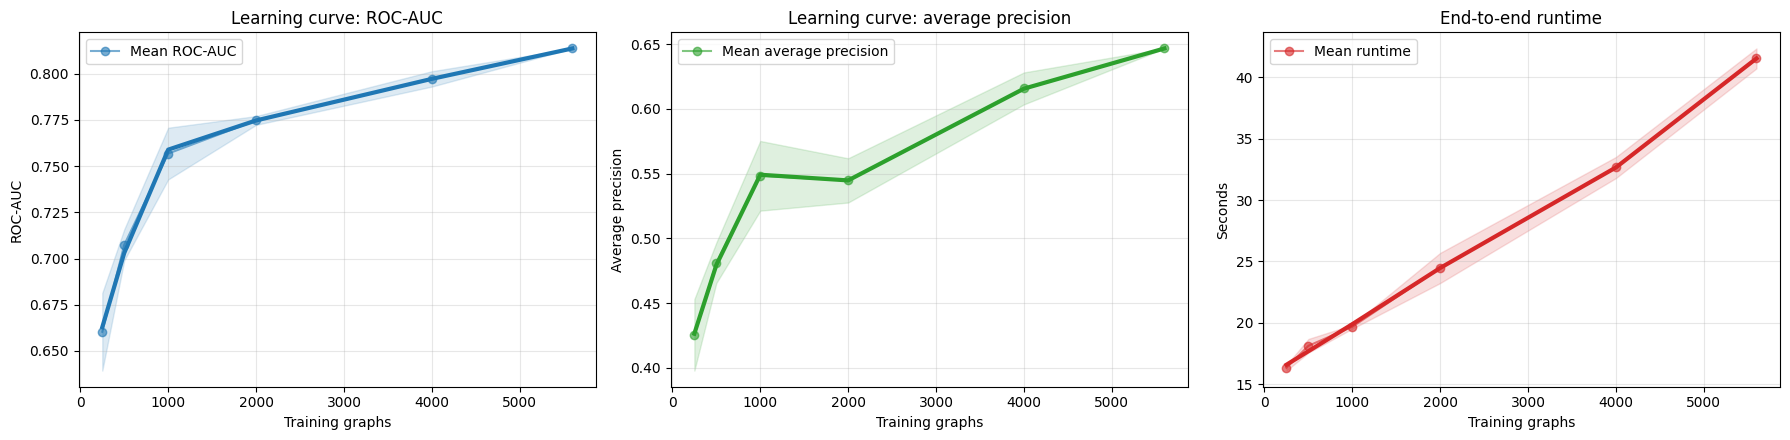

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
frac = 0.8  # Local quadratic LOESS span; adjust between 0 and 1 for more or less smoothing.
x = results_df['train_size'].to_numpy()

plot_series_with_band_loess(
    axes[0],
    x,
    results_df['mean_roc_auc'],
    y_std=results_df['std_roc_auc'],
    frac=frac,
    label='Mean ROC-AUC',
)
axes[0].set_xlabel('Training graphs')
axes[0].set_ylabel('ROC-AUC')
axes[0].set_title('Learning curve: ROC-AUC')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

plot_series_with_band_loess(
    axes[1],
    x,
    results_df['mean_avg_precision'],
    y_std=results_df['std_avg_precision'],
    frac=frac,
    color='tab:green',
    label='Mean average precision',
)
axes[1].set_xlabel('Training graphs')
axes[1].set_ylabel('Average precision')
axes[1].set_title('Learning curve: average precision')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plot_series_with_band_loess(
    axes[2],
    x,
    results_df['mean_runtime_sec'],
    y_std=results_df['std_runtime_sec'],
    frac=frac,
    color='tab:red',
    label='Mean runtime',
)
axes[2].set_xlabel('Training graphs')
axes[2].set_ylabel('Seconds')
axes[2].set_title('End-to-end runtime')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()
